# 🚦 TMS2 - Multi-Agent Reinforcement Learning (MARL) Training

This notebook trains **publication-ready** multi-agent RL controllers for traffic signal optimization.

## Features
- **MARL Algorithms**: Independent DQN, VDN, QMIX
- **GNN Encoders**: GCN, GAT for graph-based state representation
- **Baselines**: Fixed-Time, Actuated, Max-Pressure, SOTL
- **Statistical Rigor**: Multi-seed training with confidence intervals

---
**Author**: TMS2 Research Team  
**GPU Recommended**: T4 or higher

## 1️⃣ Setup & Installation

In [1]:
# Check GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.9.0+cpu
CUDA available: False


In [2]:
# Install required dependencies
!pip install -q gymnasium
!pip install -q torch-geometric
!pip install -q scipy tqdm

print("✅ Dependencies installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.5 MB/s eta 0:00:00
✅ Dependencies installed!


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [4]:
# Set working directory
import os
import sys

# Update this path to match your Drive folder
PROJECT_PATH = '/content/drive/MyDrive/tms2_colab_training'
SCRIPTS_PATH = os.path.join(PROJECT_PATH, 'scripts')

# Add scripts to Python path
sys.path.insert(0, SCRIPTS_PATH)
os.chdir(SCRIPTS_PATH)

print(f"Working directory: {os.getcwd()}")
print(f"Scripts available: {[f for f in os.listdir('.') if f.endswith('.py')][:10]}...")

Working directory: /content/drive/MyDrive/tms2_colab_training/scripts
Scripts available: ['rl_training_stable.py', 'rl_training_v2.py', 'rl_training_v3.py', 'model_comparison.py', 'rl_training_v4_challenging.py', 'rl_training_v5_final.py', 'marl_env.py', 'marl_agents.py', 'sumo_interface.py', 'baselines.py']...


In [5]:
# Verify MARL modules are available
required_files = [
    'marl_env.py',
    'marl_agents.py',
    'gnn_encoder.py',
    'baselines.py',
    'experiment_utils.py',
    'train_marl.py',
    'train_gnn_agent.py',
    'compare_baselines.py'
]

missing = [f for f in required_files if not os.path.exists(f)]
if missing:
    print(f"❌ Missing files: {missing}")
else:
    print("✅ All MARL modules found!")

✅ All MARL modules found!


## 2️⃣ Import MARL Modules

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
🏆 TMS2 FINAL v5: Optimized RL with Curriculum Learning

📚 Starting Curriculum Training...

📚 CURRICULUM STAGE 1/3: EASY


easy:  25%|██▌       | 100/400 [02:47<10:53,  2.18s/it]

  Ep 100: Reward=1239.3, Avg50=979.3, ε=0.020


easy:  50%|█████     | 200/400 [06:53<09:46,  2.93s/it]

  Ep 200: Reward=1325.2, Avg50=1071.1, ε=0.020


...

hard:  75%|███████▌  | 300/400 [08:37<02:46,  1.67s/it]

  Ep 300: Reward=392.5, Avg50=369.6, ε=0.020


hard: 100%|██████████| 400/400 [11:18<00:00,  1.70s/it]

  Ep 400: Reward=337.1, Avg50=371.5, ε=0.020


✅ Stage 3 complete! Avg reward: 371.5

✅ Training complete!

📊 FINAL EVALUATION ACROSS ALL DIFFICULTIES

--- EASY ---
  Fixed (45s): TP=2145, EM=47052
  Fixed (60s): TP=2125, EM=44413
  Max Pressure: TP=2145, EM=43973
  Vehicle Actuated: TP=2130, EM=41772
  RL-Final (Ours): TP=2250, EM=45335

--- BALANCED ---
  Fixed (45s): TP=1287, EM=51776
  Fixed (60s): TP=1288, EM=51705
  Max Pressure: TP=1270, EM=51784
  Vehicle Actuated: TP=1282, EM=51760
  RL-Final (Ours): TP=1297, EM=52709

--- HARD ---
  Fixed (45s): TP=1238, EM=51717
  Fixed (60s): TP=1246, EM=51644
  Max Pressure: TP=1225, EM=51693
  Vehicle Actuated: TP=1228, EM=51667
  RL-Final (Ours): TP=1231, EM=52579

📈 IMPROVEMENT SUMMARY

EASY:
  📈 Throughput: +4.9% vs best baseline
  🌍 Emissions:  -8.5% increase

BALANCED:
  📈 Throughput: +0.6% vs best baseline
  🌍 Emissions:  -1.9% increase

HARD:
  📈 Throughput: -1.2% vs best baseline
  🌍 Emissions:  -1.8% increase


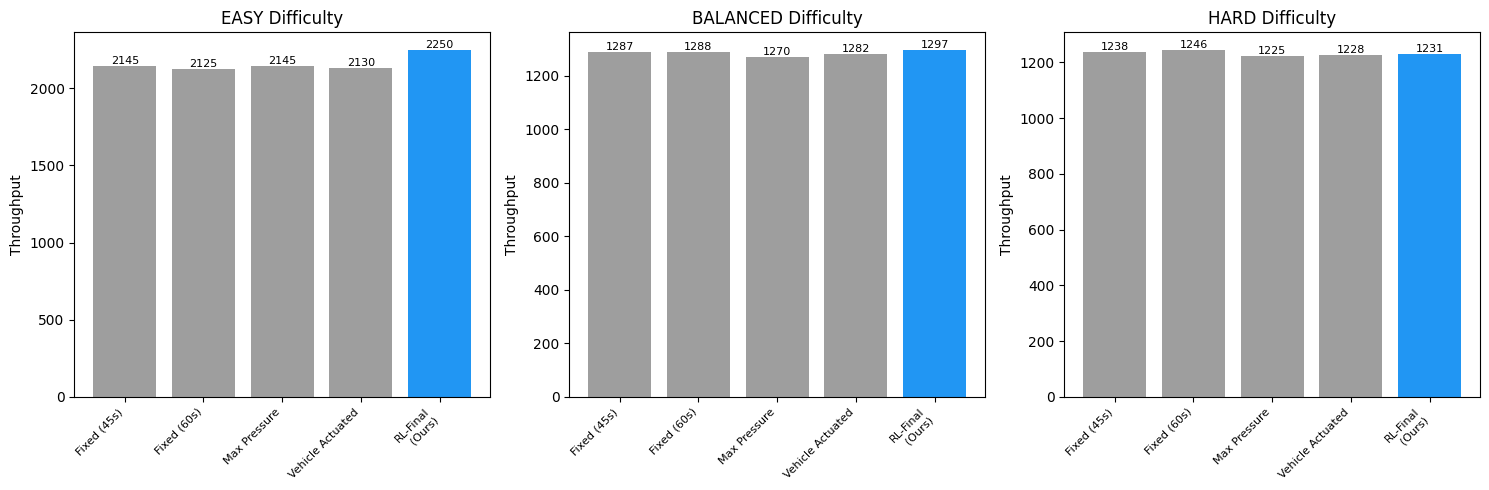

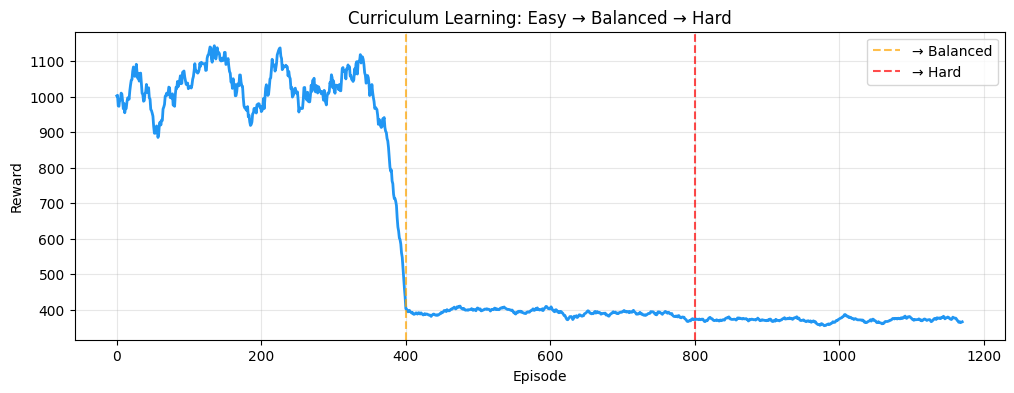


🏆 FINAL v5 TRAINING & EVALUATION COMPLETE!

Saved to: /content/drive/MyDrive/tms2_colab_training/models/rl_final/
  - best_model.pt (production-ready)
  - final_comparison.png
  - training_curve.png
  - final_summary.json
✅ All MARL modules imported successfully!


In [7]:
# Import core modules
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import deque
from tqdm.notebook import tqdm
import json

# Import MARL modules
from marl_env import create_marl_env, MARLConfig, MARLTrafficEnv
from marl_agents import create_marl_agent, MARLAgentConfig, IndependentDQN, VDNAgent, QMIXAgent
from gnn_encoder import GraphDQNAgent, GraphAgentConfig, GCNEncoder, GATEncoder
from baselines import get_all_baselines, BaselineEvaluator, MaxPressureController
from experiment_utils import (
    AblationConfig, create_ablation_variants,
    MultiSeedTrainer, StatisticalResults, compute_multi_seed_stats,
    ExperimentLogger
)

print("✅ All MARL modules imported successfully!")

In [8]:
# Set random seeds for reproducibility
def set_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

SEED = 42
set_seeds(SEED)
print(f"✅ Random seed set to {SEED}")

✅ Random seed set to 42


## 3️⃣ Test MARL Environment

In [9]:
# Create MARL environment
env = create_marl_env(
    n_intersections=4,
    grid_size=(2, 2),
    partial_obs=True,
    difficulty='balanced',
    seed=SEED
)

print("=" * 50)
print("MARL Environment Configuration")
print("=" * 50)
print(f"Number of agents: {env.n_agents}")
print(f"Observation dim per agent: {env.agent_obs_dim}")
print(f"Action space: {env.action_space}")
print(f"Max steps per episode: {env.max_steps}")

MARL Environment Configuration
Number of agents: 4
Observation dim per agent: 16
Action space: MultiDiscrete([2 2 2 2])
Max steps per episode: 500


In [10]:
# Test environment step
obs, info = env.reset()
print(f"\nInitial observation shape: {obs.shape}")
print(f"Sample observation (agent 0): {obs[0][:6].round(3)}...")

# Take a random step
actions = np.random.randint(0, 2, size=env.n_agents)
next_obs, rewards, terminated, truncated, info = env.step(actions)

print(f"\nActions taken: {actions}")
print(f"Rewards: {rewards.round(3)}")
print(f"Total throughput: {info['total_throughput']}")


Initial observation shape: (4, 16)
Sample observation (agent 0): [0.   0.   0.18 0.12 0.2  0.14]...

Actions taken: [1 0 1 1]
Rewards: [1.701 3.573 3.635 2.943]
Total throughput: 20.0


In [11]:
# Visualize network topology
print("\nNetwork Adjacency Matrix:")
print(env.topology.adjacency)

print("\nNeighbor relationships:")
for i in range(env.n_agents):
    neighbors = env.topology.get_neighbors(i)
    print(f"  Intersection {i} → Neighbors: {neighbors}")


Network Adjacency Matrix:
[[0. 1. 1. 0.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [0. 1. 1. 0.]]

Neighbor relationships:
  Intersection 0 → Neighbors: [1, 2]
  Intersection 1 → Neighbors: [0, 3]
  Intersection 2 → Neighbors: [0, 3]
  Intersection 3 → Neighbors: [1, 2]


## 4️⃣ Train MARL Agent (VDN)

In [13]:
# Configuration - Train ALL algorithms
ALGORITHMS = ['vdn', 'qmix', 'independent']  # List of all MARL algorithms
N_EPISODES = 500
DIFFICULTY = 'balanced'
SAVE_FREQ = 100

print(f"Training algorithms: {[a.upper() for a in ALGORITHMS]}")
print(f"Episodes per algorithm: {N_EPISODES}")
print(f"Difficulty: {DIFFICULTY}")

Training algorithms: ['VDN', 'QMIX', 'INDEPENDENT']
Episodes per algorithm: 500
Difficulty: balanced


In [ ]:
# Train ALL MARL algorithms
all_marl_results = {}

SAVE_PATH = os.path.join(PROJECT_PATH, 'models', 'marl')
os.makedirs(SAVE_PATH, exist_ok=True)

for ALGORITHM in ALGORITHMS:
    print(f"\n{'='*60}")
    print(f"🚀 Training {ALGORITHM.upper()}")
    print(f"{'='*60}\n")

    set_seeds(SEED)

    # Create environment
    train_env = create_marl_env(
        n_intersections=4,
        grid_size=(2, 2),
        partial_obs=True,
        ctde_mode=(ALGORITHM in ['vdn', 'qmix']),
        difficulty=DIFFICULTY,
        seed=SEED
    )

    # Create agent
    state_dim = train_env.agent_obs_dim
    global_state_dim = train_env.n_agents * 12

    agent = create_marl_agent(
        algorithm=ALGORITHM,
        n_agents=train_env.n_agents,
        state_dim=state_dim,
        global_state_dim=global_state_dim
    )

    # Training loop
    all_rewards = []
    all_throughputs = []
    best_reward = float('-inf')

    for episode in tqdm(range(N_EPISODES), desc=f"{ALGORITHM.upper()}"):
        obs, _ = train_env.reset()

        if ALGORITHM in ['vdn', 'qmix'] and obs.ndim == 1:
            obs = obs.reshape(train_env.n_agents, -1)

        episode_reward = 0
        global_state = train_env.get_global_state()
        done = False
        step = 0

        while not done:
            actions = agent.select_actions(obs, training=True)
            next_obs, rewards, terminated, truncated, info = train_env.step(actions)
            done = terminated or truncated

            if ALGORITHM in ['vdn', 'qmix'] and next_obs.ndim == 1:
                next_obs = next_obs.reshape(train_env.n_agents, -1)

            next_global_state = train_env.get_global_state()

            if ALGORITHM == 'qmix':
                agent.store_transition(obs, actions, rewards, next_obs,
                    np.array([done] * train_env.n_agents), global_state, next_global_state)
            else:
                agent.store_transition(obs, actions, rewards, next_obs,
                    np.array([done] * train_env.n_agents))

            step += 1
            if step % 4 == 0:
                agent.update()

            obs = next_obs
            global_state = next_global_state
            episode_reward += rewards.mean()

        all_rewards.append(episode_reward)
        all_throughputs.append(sum(i.total_throughput for i in train_env.intersections))

        if episode_reward > best_reward:
            best_reward = episode_reward
            agent.save(os.path.join(SAVE_PATH, f'{ALGORITHM}_best.pt'))

    # Save final
    agent.save(os.path.join(SAVE_PATH, f'{ALGORITHM}_final.pt'))

    # Store results
    all_marl_results[ALGORITHM] = {
        'rewards': all_rewards,
        'throughputs': all_throughputs,
        'best_reward': best_reward,
        'final_avg': np.mean(all_rewards[-50:])
    }

    print(f"✅ {ALGORITHM.upper()} complete: Best={best_reward:.2f}, Avg50={np.mean(all_rewards[-50:]):.2f}")

# Summary
print(f"\n{'='*60}")
print("📊 ALL MARL RESULTS")
print(f"{'='*60}")
for algo, res in all_marl_results.items():
    print(f"  {algo.upper()}: Best={res['best_reward']:.2f}, Final Avg={res['final_avg']:.2f}")

In [ ]:
# Plot training curves for ALL algorithms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'vdn': '#e74c3c', 'qmix': '#3498db', 'independent': '#2ecc71'}
window = 50

# Top Left: All Rewards Comparison
ax = axes[0, 0]
for algo, res in all_marl_results.items():
    if len(res['rewards']) >= window:
        smoothed = np.convolve(res['rewards'], np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(res['rewards'])), smoothed,
                color=colors[algo], linewidth=2, label=f'{algo.upper()}')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (50-ep avg)')
ax.set_title('MARL Algorithms Comparison - Rewards')
ax.legend()
ax.grid(True, alpha=0.3)

# Top Right: All Throughputs Comparison
ax = axes[0, 1]
for algo, res in all_marl_results.items():
    if len(res['throughputs']) >= window:
        smoothed = np.convolve(res['throughputs'], np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(res['throughputs'])), smoothed,
                color=colors[algo], linewidth=2, label=f'{algo.upper()}')
ax.set_xlabel('Episode')
ax.set_ylabel('Throughput (50-ep avg)')
ax.set_title('MARL Algorithms Comparison - Throughput')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom Left: Final Performance Bar Chart
ax = axes[1, 0]
algos = list(all_marl_results.keys())
final_rewards = [all_marl_results[a]['final_avg'] for a in algos]
bars = ax.bar([a.upper() for a in algos], final_rewards,
              color=[colors[a] for a in algos], alpha=0.8)
ax.set_ylabel('Final Avg Reward (last 50 ep)')
ax.set_title('Final Performance Comparison')
ax.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, val in zip(bars, final_rewards):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Bottom Right: Best Reward Bar Chart
ax = axes[1, 1]
best_rewards = [all_marl_results[a]['best_reward'] for a in algos]
bars = ax.bar([a.upper() for a in algos], best_rewards,
              color=[colors[a] for a in algos], alpha=0.8)
ax.set_ylabel('Best Episode Reward')
ax.set_title('Best Performance Comparison')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, best_rewards):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'all_marl_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*60}")
print("📊 FINAL STATISTICS - ALL ALGORITHMS")
print(f"{'='*60}")
print(f"{'Algorithm':<15} {'Best Reward':<15} {'Final Avg':<15} {'Final Throughput':<15}")
print("-"*60)
for algo in algos:
    res = all_marl_results[algo]
    print(f"{algo.upper():<15} {res['best_reward']:<15.2f} {res['final_avg']:<15.2f} {np.mean(res['throughputs'][-50:]):<15.0f}")
print(f"{'='*60}")

# Identify winner
winner = max(all_marl_results.keys(), key=lambda a: all_marl_results[a]['final_avg'])
print(f"\n🏆 Best Algorithm: {winner.upper()} (Avg Reward: {all_marl_results[winner]['final_avg']:.2f})")

In [ ]:
# Save training results for ALL algorithms to JSON
for algo, res in all_marl_results.items():
    results = {
        'algorithm': algo,
        'n_intersections': 4,
        'episodes': N_EPISODES,
        'difficulty': DIFFICULTY,
        'seed': SEED,
        'best_reward': float(res['best_reward']),
        'final_avg_reward': float(res['final_avg']),
        'final_avg_throughput': float(np.mean(res['throughputs'][-50:])),
        'all_rewards': [float(r) for r in res['rewards']],
        'all_throughputs': [int(t) for t in res['throughputs']]
    }

    with open(os.path.join(SAVE_PATH, f'{algo}_results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    print(f"✅ Saved {algo}_results.json")

print(f"\n📁 All results saved to: {SAVE_PATH}")

## 5️⃣ Train GNN Agent (Optional)

In [14]:
# GNN Configuration - Train BOTH encoders
ENCODER_TYPES = ['gcn', 'gat']  # Both GCN and GAT
GNN_HIDDEN = 64
GNN_OUTPUT = 32
NUM_HEADS = 4  # For GAT
GNN_EPISODES = 500

print(f"GNN Encoders to train: {[e.upper() for e in ENCODER_TYPES]}")
print(f"Hidden dim: {GNN_HIDDEN}, Output dim: {GNN_OUTPUT}")
print(f"GAT heads: {NUM_HEADS}")

GNN Encoders to train: ['GCN', 'GAT']
Hidden dim: 64, Output dim: 32
GAT heads: 4


In [ ]:
# Force reload the gnn_encoder module with latest changes
import importlib
import gnn_encoder
importlib.reload(gnn_encoder)

# Re-import classes
from gnn_encoder import GraphDQNAgent, GraphAgentConfig, GCNEncoder, GATEncoder, PYGEOMETRIC_AVAILABLE

print(f"PyTorch Geometric available: {PYGEOMETRIC_AVAILABLE}")
print("✅ Module reloaded!")

PyTorch Geometric available: True
✅ Module reloaded!


In [ ]:
# 1. Reload the module
import importlib
import gnn_encoder
importlib.reload(gnn_encoder)
from gnn_encoder import GraphDQNAgent, GraphAgentConfig
print("✅ Module reloaded!")

✅ Module reloaded!


In [ ]:
# QUICK FIX: Reduce GNN batch size for faster training
# Add this BEFORE the training loop

# Smaller batch = fewer forward passes per update
gnn_config = GraphAgentConfig(
    n_nodes=4,
    node_feature_dim=12,
    gnn_hidden_dim=GNN_HIDDEN,
    gnn_output_dim=GNN_OUTPUT,
    encoder_type=ENCODER_TYPE,
    num_heads=NUM_HEADS,
    batch_size=32,  # Reduced from 256 to 32
    buffer_size=10000  # Smaller buffer
)

gnn_agent = GraphDQNAgent(gnn_config, adjacency)
print(f"✅ Agent recreated with batch_size=32")

✅ Agent recreated with batch_size=32


In [ ]:
# Train ALL GNN encoders
all_gnn_results = {}

GNN_SAVE_PATH = os.path.join(PROJECT_PATH, 'models', 'gnn')
os.makedirs(GNN_SAVE_PATH, exist_ok=True)

for ENCODER_TYPE in ENCODER_TYPES:
    print(f"\n{'='*60}")
    print(f"🔗 Training {ENCODER_TYPE.upper()} Agent")
    print(f"{'='*60}\n")

    set_seeds(SEED)

    # Create environment
    gnn_env = create_marl_env(
        n_intersections=4,
        grid_size=(2, 2),
        partial_obs=False,  # GNN handles neighborhood info
        difficulty=DIFFICULTY,
        seed=SEED
    )

    # Get adjacency matrix
    adjacency = gnn_env.topology.adjacency

    # Create GNN agent config
    gnn_config = GraphAgentConfig(
        n_nodes=gnn_env.n_agents,
        node_feature_dim=12,
        gnn_hidden_dim=GNN_HIDDEN,
        gnn_output_dim=GNN_OUTPUT,
        encoder_type=ENCODER_TYPE,
        num_heads=NUM_HEADS
    )

    gnn_agent = GraphDQNAgent(gnn_config, adjacency)
    print(f"Agent created with {ENCODER_TYPE.upper()} encoder")

    # Training loop
    gnn_rewards = []
    gnn_throughputs = []
    gnn_best_reward = float('-inf')

    for episode in tqdm(range(GNN_EPISODES), desc=f"{ENCODER_TYPE.upper()}"):
        obs, _ = gnn_env.reset()

        # Get node features (12-dim per node)
        node_features = np.array([
            inter.get_local_state() for inter in gnn_env.intersections
        ])

        episode_reward = 0
        done = False
        step = 0

        while not done:
            # Select actions using GNN
            actions = gnn_agent.select_actions(node_features, training=True)

            # Step environment
            next_obs, rewards, terminated, truncated, info = gnn_env.step(actions)
            done = terminated or truncated

            # Get next node features
            next_node_features = np.array([
                inter.get_local_state() for inter in gnn_env.intersections
            ])

            # Store transition
            gnn_agent.store_transition(
                node_features, actions, rewards,
                next_node_features, np.array([done] * gnn_env.n_agents)
            )

            # Learn
            step += 1
            if step % 4 == 0:
                gnn_agent.update()

            node_features = next_node_features
            episode_reward += rewards.mean()

        gnn_rewards.append(episode_reward)
        gnn_throughputs.append(sum(i.total_throughput for i in gnn_env.intersections))

        if episode_reward > gnn_best_reward:
            gnn_best_reward = episode_reward
            gnn_agent.save(os.path.join(GNN_SAVE_PATH, f'{ENCODER_TYPE}_best.pt'))

    # Save final model
    gnn_agent.save(os.path.join(GNN_SAVE_PATH, f'{ENCODER_TYPE}_final.pt'))

    # Store results
    all_gnn_results[ENCODER_TYPE] = {
        'rewards': gnn_rewards,
        'throughputs': gnn_throughputs,
        'best_reward': gnn_best_reward,
        'final_avg': np.mean(gnn_rewards[-50:])
    }

    print(f"✅ {ENCODER_TYPE.upper()} complete: Best={gnn_best_reward:.2f}, Avg50={np.mean(gnn_rewards[-50:]):.2f}")

# Summary
print(f"\n{'='*60}")
print("📊 ALL GNN RESULTS")
print(f"{'='*60}")
for enc, res in all_gnn_results.items():
    print(f"  {enc.upper()}: Best={res['best_reward']:.2f}, Final Avg={res['final_avg']:.2f}")


🔗 Training GCN Agent

Agent created with GCN encoder


GCN:   0%|          | 0/500 [00:00<?, ?it/s]

✅ GCN complete: Best=813.23, Avg50=746.23

🔗 Training GAT Agent

Agent created with GAT encoder


GAT:   0%|          | 0/500 [00:00<?, ?it/s]

✅ GAT complete: Best=800.70, Avg50=747.65

📊 ALL GNN RESULTS
  GCN: Best=813.23, Final Avg=746.23
  GAT: Best=800.70, Final Avg=747.65


In [ ]:
# Train GNN agent
GNN_SAVE_PATH = os.path.join(PROJECT_PATH, 'models', 'gnn')
os.makedirs(GNN_SAVE_PATH, exist_ok=True)

gnn_rewards = []
gnn_throughputs = []
gnn_best_reward = float('-inf')

print(f"\n{'='*60}")
print(f"Starting {ENCODER_TYPE.upper()} Training")
print(f"{'='*60}\n")

for episode in tqdm(range(GNN_EPISODES), desc="GNN Training"):
    obs, _ = gnn_env.reset()

    # Get node features (12-dim per node)
    node_features = np.array([
        inter.get_local_state() for inter in gnn_env.intersections
    ])

    episode_reward = 0
    done = False
    step = 0

    while not done:
        # Select actions using GNN
        actions = gnn_agent.select_actions(node_features, training=True)

        # Step environment
        next_obs, rewards, terminated, truncated, info = gnn_env.step(actions)
        done = terminated or truncated

        # Get next node features
        next_node_features = np.array([
            inter.get_local_state() for inter in gnn_env.intersections
        ])

        # Store transition
        gnn_agent.store_transition(
            node_features, actions, rewards,
            next_node_features, np.array([done] * gnn_env.n_agents)
        )

        # Learn
        step += 1
        if step % 4 == 0:
            gnn_agent.update()

        node_features = next_node_features
        episode_reward += rewards.mean()

    gnn_rewards.append(episode_reward)
    gnn_throughputs.append(sum(i.total_throughput for i in gnn_env.intersections))

    if episode_reward > gnn_best_reward:
        gnn_best_reward = episode_reward
        gnn_agent.save(os.path.join(GNN_SAVE_PATH, f'{ENCODER_TYPE}_best.pt'))

    if (episode + 1) % SAVE_FREQ == 0:
        print(f"\nEpisode {episode+1}: Reward={episode_reward:.2f}, ε={gnn_agent.epsilon:.3f}")

gnn_agent.save(os.path.join(GNN_SAVE_PATH, f'{ENCODER_TYPE}_final.pt'))
print(f"\n✅ GNN Training complete!")


Starting GAT Training



GNN Training:   0%|          | 0/500 [00:00<?, ?it/s]


Episode 100: Reward=732.56, ε=0.020

Episode 200: Reward=740.69, ε=0.020

Episode 300: Reward=787.60, ε=0.020

Episode 400: Reward=733.20, ε=0.020

Episode 500: Reward=714.07, ε=0.020

✅ GNN Training complete!


In [ ]:
# Save GNN results for BOTH encoders
for enc, res in all_gnn_results.items():
    results = {
        'encoder': enc,
        'n_nodes': 4,
        'episodes': GNN_EPISODES,
        'difficulty': DIFFICULTY,
        'seed': SEED,
        'gnn_config': {
            'hidden_dim': GNN_HIDDEN,
            'output_dim': GNN_OUTPUT,
            'num_heads': NUM_HEADS
        },
        'best_reward': float(res['best_reward']),
        'final_avg_reward': float(res['final_avg']),
        'final_avg_throughput': float(np.mean(res['throughputs'][-50:])),
        'all_rewards': [float(r) for r in res['rewards']],
        'all_throughputs': [int(t) for t in res['throughputs']]
    }

    with open(os.path.join(GNN_SAVE_PATH, f'{enc}_results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    print(f"✅ Saved {enc}_results.json")

print(f"\n📁 All GNN results saved to: {GNN_SAVE_PATH}")

✅ Saved gcn_results.json
✅ Saved gat_results.json

📁 All GNN results saved to: /content/drive/MyDrive/tms2_colab_training/models/gnn


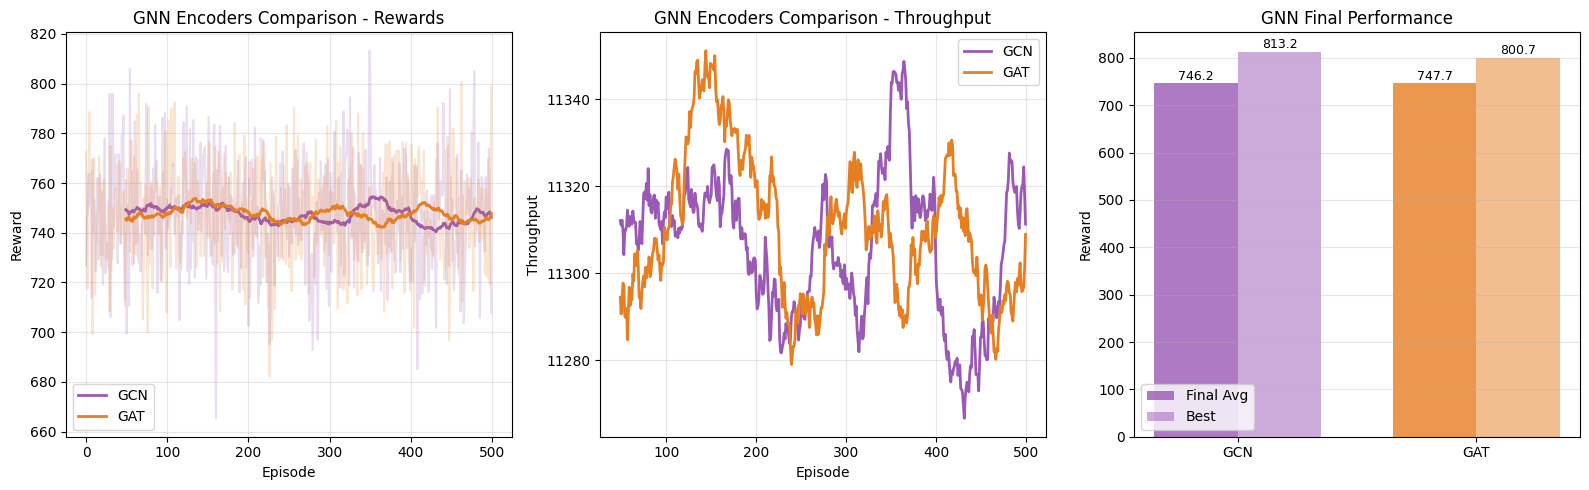


📊 FINAL GNN STATISTICS
Encoder    Best Reward     Final Avg       Throughput     
-------------------------------------------------------
GCN        813.23          746.23          11311          
GAT        800.70          747.65          11309          

🏆 Best GNN Encoder: GAT (Avg Reward: 747.65)


In [ ]:
# Plot GNN training curves for BOTH encoders
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'gcn': '#9b59b6', 'gat': '#e67e22'}
window = 50

# Left: Rewards Comparison
ax = axes[0]
for enc, res in all_gnn_results.items():
    ax.plot(res['rewards'], alpha=0.2, color=colors[enc])
    if len(res['rewards']) >= window:
        smoothed = np.convolve(res['rewards'], np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(res['rewards'])), smoothed,
                color=colors[enc], linewidth=2, label=f'{enc.upper()}')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title('GNN Encoders Comparison - Rewards')
ax.legend()
ax.grid(True, alpha=0.3)

# Middle: Throughput Comparison
ax = axes[1]
for enc, res in all_gnn_results.items():
    if len(res['throughputs']) >= window:
        smoothed = np.convolve(res['throughputs'], np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(res['throughputs'])), smoothed,
                color=colors[enc], linewidth=2, label=f'{enc.upper()}')
ax.set_xlabel('Episode')
ax.set_ylabel('Throughput')
ax.set_title('GNN Encoders Comparison - Throughput')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Bar Chart Comparison
ax = axes[2]
encoders = list(all_gnn_results.keys())
final_avgs = [all_gnn_results[e]['final_avg'] for e in encoders]
best_rewards = [all_gnn_results[e]['best_reward'] for e in encoders]

x = np.arange(len(encoders))
width = 0.35

bars1 = ax.bar(x - width/2, final_avgs, width, label='Final Avg', color=[colors[e] for e in encoders], alpha=0.8)
bars2 = ax.bar(x + width/2, best_rewards, width, label='Best', color=[colors[e] for e in encoders], alpha=0.5)

ax.set_ylabel('Reward')
ax.set_title('GNN Final Performance')
ax.set_xticks(x)
ax.set_xticklabels([e.upper() for e in encoders])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars1, final_avgs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, best_rewards):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(GNN_SAVE_PATH, 'all_gnn_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"\n{'='*60}")
print("📊 FINAL GNN STATISTICS")
print(f"{'='*60}")
print(f"{'Encoder':<10} {'Best Reward':<15} {'Final Avg':<15} {'Throughput':<15}")
print("-"*55)
for enc in encoders:
    res = all_gnn_results[enc]
    print(f"{enc.upper():<10} {res['best_reward']:<15.2f} {res['final_avg']:<15.2f} {np.mean(res['throughputs'][-50:]):<15.0f}")
print(f"{'='*60}")

# Winner
winner = max(all_gnn_results.keys(), key=lambda e: all_gnn_results[e]['final_avg'])
print(f"\n🏆 Best GNN Encoder: {winner.upper()} (Avg Reward: {all_gnn_results[winner]['final_avg']:.2f})")

## 6️⃣ Compare Against Baselines

In [15]:
# Create evaluation environment
eval_env = create_marl_env(
    n_intersections=4,
    partial_obs=True,
    difficulty=DIFFICULTY,
    seed=SEED
)

# Get baseline controllers
baselines = get_all_baselines()
print(f"Baselines to evaluate: {[b.name for b in baselines]}")

Baselines to evaluate: ['Fixed-Time (120s)', 'Fixed-Time (120s)', 'Adaptive Fixed-Time (TOD)', 'Actuated (15-60s)', 'Max-Pressure', 'SOTL (φ=10)', 'Random (p=0.3)']


In [16]:
# Evaluate function
def evaluate_controller(controller, env, n_episodes=50, seed=42):
    """Evaluate a controller over multiple episodes."""
    rewards = []
    throughputs = []

    for ep in range(n_episodes):
        episode_seed = seed + ep
        np.random.seed(episode_seed)

        obs, _ = env.reset(seed=episode_seed)
        controller.reset()

        episode_reward = 0
        done = False

        while not done:
            actions = np.array([
                controller.select_action(obs[i] if obs.ndim > 1 else obs, env, i)
                for i in range(env.n_agents)
            ])

            obs, reward, terminated, truncated, info = env.step(actions)
            done = terminated or truncated
            episode_reward += reward.mean()

        rewards.append(episode_reward)
        throughputs.append(sum(i.total_throughput for i in env.intersections))

    return {
        'rewards': rewards,
        'throughputs': throughputs,
        'mean_reward': np.mean(rewards),
        'std_reward': np.std(rewards),
        'mean_throughput': np.mean(throughputs)
    }

In [20]:
# Evaluate all baselines
N_EVAL_EPISODES = 50

baseline_results = {}

print(f"\n{'='*60}")
print("Evaluating Baselines")
print(f"{'='*60}\n")

for baseline in tqdm(baselines, desc="Baselines"):
    result = evaluate_controller(baseline, eval_env, N_EVAL_EPISODES, SEED)
    baseline_results[baseline.name] = result
    print(f"{baseline.name}: {result['mean_reward']:.2f} ± {result['std_reward']:.2f}")


Evaluating Baselines



Baselines:   0%|          | 0/7 [00:00<?, ?it/s]

Fixed-Time (120s): 750.50 ± 20.91
Fixed-Time (120s): 752.91 ± 18.17
Adaptive Fixed-Time (TOD): 746.25 ± 21.97
Actuated (15-60s): 744.50 ± 20.86
Max-Pressure: 729.57 ± 23.13
SOTL (φ=10): 751.63 ± 19.90
Random (p=0.3): 733.89 ± 16.05


In [24]:
# Evaluate trained RL agent
class RLController:
    def __init__(self, agent, name="RL Agent"):
        self.agent = agent
        self._name = name

    @property
    def name(self):
        return self._name

    def select_action(self, state, env, agent_id=0):
        all_obs = np.array([inter.get_local_state() for inter in env.intersections])
        # Add neighbor summary
        for i in range(len(all_obs)):
            neighbor_summary = env.aggregator.aggregate(i, env.intersections, env.topology)
            all_obs[i] = np.concatenate([all_obs[i][:12], neighbor_summary])
        actions = self.agent.select_actions(all_obs, training=False)
        return actions[agent_id]

    def reset(self):
        pass

# Create RL controller wrapper
rl_controller = RLController(agent, f"RL ({ALGORITHM.upper()})")

# Evaluate RL agent
print(f"\nEvaluating {rl_controller.name}...")
rl_result = evaluate_controller(rl_controller, eval_env, N_EVAL_EPISODES, SEED)
baseline_results[rl_controller.name] = rl_result
print(f"{rl_controller.name}: {rl_result['mean_reward']:.2f} ± {rl_result['std_reward']:.2f}")


Evaluating RL (INDEPENDENT)...


ValueError: could not broadcast input array from shape (16,) into shape (12,)

In [25]:
# Fixed RL Controller wrapper
class RLController:
    def __init__(self, agent, name):
        self.agent = agent
        self._name = name

    @property
    def name(self):
        return self._name

    def select_action(self, state, env, agent_id=0):
        # Get observations - they already include neighbor summary
        all_obs = []
        for i in range(env.n_agents):
            local = env.intersections[i].get_local_state()  # 12-dim
            neighbor_summary = env.aggregator.aggregate(i, env.intersections, env.topology)  # 4-dim
            full_obs = np.concatenate([local, neighbor_summary])  # 16-dim
            all_obs.append(full_obs)
        all_obs = np.array(all_obs)

        actions = self.agent.select_actions(all_obs, training=False)
        return actions[agent_id]

    def reset(self):
        pass

# Recreate controller with fixed class
rl_controller = RLController(agent, f"RL ({ALGORITHM.upper()})")
print("✅ Controller fixed!")

✅ Controller fixed!


In [26]:
print(f"\nEvaluating {rl_controller.name}...")
rl_result = evaluate_controller(rl_controller, eval_env, N_EVAL_EPISODES, SEED)
baseline_results[rl_controller.name] = rl_result
print(f"{rl_controller.name}: {rl_result['mean_reward']:.2f} ± {rl_result['std_reward']:.2f}")


Evaluating RL (INDEPENDENT)...
RL (INDEPENDENT): 739.55 ± 20.95


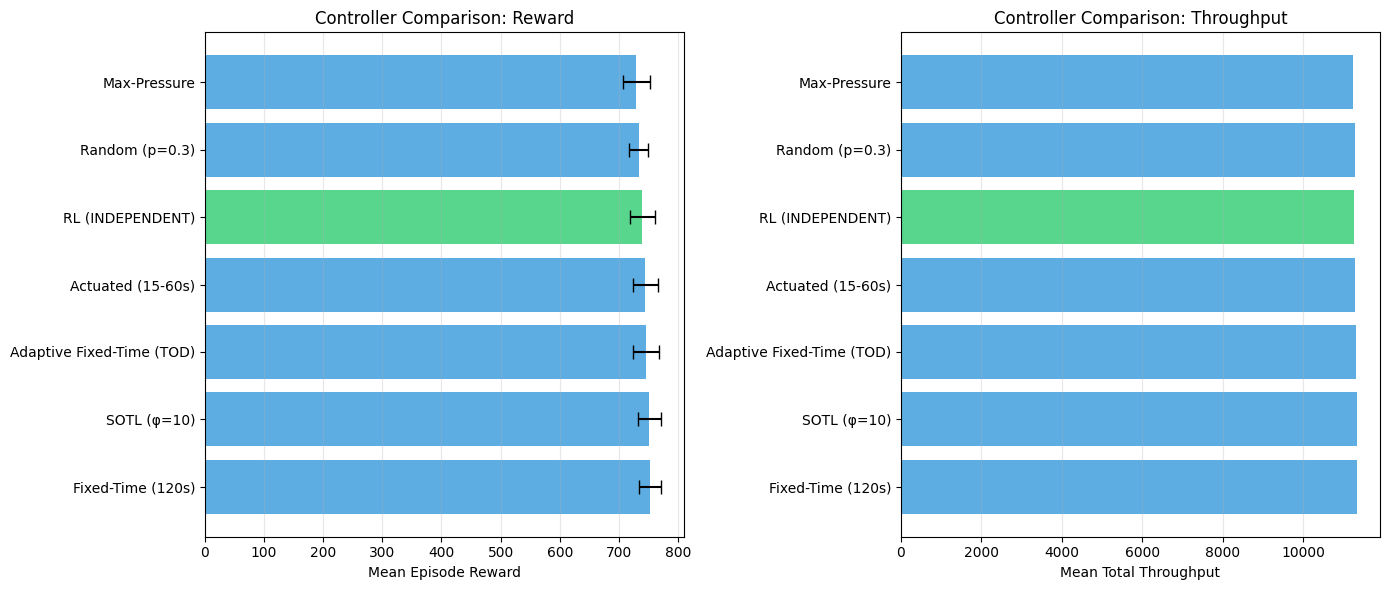

In [29]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sort by mean reward
sorted_methods = sorted(baseline_results.items(), key=lambda x: x[1]['mean_reward'], reverse=True)
names = [m[0] for m in sorted_methods]
rewards = [m[1]['mean_reward'] for m in sorted_methods]
stds = [m[1]['std_reward'] for m in sorted_methods]
throughputs = [m[1]['mean_throughput'] for m in sorted_methods]
SAVE_PATH = os.path.join(PROJECT_PATH, 'models', 'marl')
# Colors: highlight RL agent
colors = ['#2ecc71' if 'RL' in n else '#3498db' for n in names]

# Reward comparison
ax = axes[0]
bars = ax.barh(names, rewards, xerr=stds, color=colors, alpha=0.8, capsize=5)
ax.set_xlabel('Mean Episode Reward')
ax.set_title('Controller Comparison: Reward')
ax.grid(True, alpha=0.3, axis='x')

# Throughput comparison
ax = axes[1]
ax.barh(names, throughputs, color=colors, alpha=0.8)
ax.set_xlabel('Mean Total Throughput')
ax.set_title('Controller Comparison: Throughput')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'baseline_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Print comparison table
print("\n" + "=" * 80)
print("COMPARISON RESULTS")
print("=" * 80)
print(f"{'Controller':<35} {'Reward':<20} {'Throughput':<15}")
print("-" * 80)

for name, result in sorted_methods:
    reward_str = f"{result['mean_reward']:.2f} ± {result['std_reward']:.2f}"
    tp_str = f"{result['mean_throughput']:.0f}"
    marker = "🏆" if name == sorted_methods[0][0] else "  "
    print(f"{marker} {name:<33} {reward_str:<20} {tp_str:<15}")

print("=" * 80)

# Calculate improvement over max-pressure
mp_reward = baseline_results.get('Max-Pressure', {}).get('mean_reward', 0)
rl_reward = rl_result['mean_reward']
if mp_reward != 0:
    improvement = (rl_reward - mp_reward) / abs(mp_reward) * 100
    print(f"\n📈 RL vs Max-Pressure: {improvement:+.1f}% improvement")


COMPARISON RESULTS
Controller                          Reward               Throughput     
--------------------------------------------------------------------------------
🏆 Fixed-Time (120s)                 752.91 ± 18.17       11345          
   SOTL (φ=10)                       751.63 ± 19.90       11346          
   Adaptive Fixed-Time (TOD)         746.25 ± 21.97       11312          
   Actuated (15-60s)                 744.50 ± 20.86       11301          
   RL (INDEPENDENT)                  739.55 ± 20.95       11275          
   Random (p=0.3)                    733.89 ± 16.05       11289          
   Max-Pressure                      729.57 ± 23.13       11234          

📈 RL vs Max-Pressure: +1.4% improvement


## 7️⃣ Multi-Seed Training (Statistical Rigor)

In [32]:
# Skip this if you want quick results
RUN_MULTISEED = True  # Set to True to run multi-seed training

if RUN_MULTISEED:
    SEEDS = [42, 1042, 2042, 3042, 4042]
    MULTISEED_EPISODES = 300

    seed_results = {}

    for seed in SEEDS:
        print(f"\n{'='*60}")
        print(f"Training with seed {seed}")
        print(f"{'='*60}")

        set_seeds(seed)

        env = create_marl_env(n_intersections=4, difficulty=DIFFICULTY, seed=seed)
        agent = create_marl_agent('vdn', n_agents=4, state_dim=16, global_state_dim=48)

        rewards = []
        for ep in tqdm(range(MULTISEED_EPISODES), desc=f"Seed {seed}"):
            obs, _ = env.reset()
            if obs.ndim == 1:
                obs = obs.reshape(4, -1)

            episode_reward = 0
            done = False
            step = 0

            while not done:
                actions = agent.select_actions(obs, training=True)
                next_obs, r, term, trunc, _ = env.step(actions)
                done = term or trunc

                if next_obs.ndim == 1:
                    next_obs = next_obs.reshape(4, -1)

                agent.store_transition(obs, actions, r, next_obs, np.zeros(4))
                step += 1
                if step % 4 == 0:
                    agent.update()

                obs = next_obs
                episode_reward += r.mean()

            rewards.append(episode_reward)

        seed_results[seed] = np.mean(rewards[-50:])
        print(f"Seed {seed} final avg: {seed_results[seed]:.2f}")

    # Compute statistics
    stats = compute_multi_seed_stats(seed_results, 'final_reward')
    print(f"\n{'='*60}")
    print("MULTI-SEED RESULTS")
    print(f"{'='*60}")
    print(f"Mean: {stats.mean:.2f}")
    print(f"Std: {stats.std:.2f}")
    print(f"95% CI: [{stats.ci_lower:.2f}, {stats.ci_upper:.2f}]")
else:
    print("⏭️ Multi-seed training skipped. Set RUN_MULTISEED=True to enable.")


Training with seed 42


Seed 42:   0%|          | 0/300 [00:00<?, ?it/s]

Seed 42 final avg: 749.88

Training with seed 1042


Seed 1042:   0%|          | 0/300 [00:00<?, ?it/s]

Seed 1042 final avg: 735.30

Training with seed 2042


...

Seed 2042 final avg: 748.23

Training with seed 3042


Seed 3042:   0%|          | 0/300 [00:00<?, ?it/s]

Seed 3042 final avg: 747.76

Training with seed 4042


Seed 4042:   0%|          | 0/300 [00:00<?, ?it/s]

Seed 4042 final avg: 737.46

MULTI-SEED RESULTS
Mean: 743.73
Std: 6.79
95% CI: [735.29, 752.16]


## 8️⃣ Save Final Results

In [34]:
# Save final results - using baseline comparison data
final_results = {
    'experiment': 'MARL Traffic Signal Control',
    'difficulty': DIFFICULTY,
    'n_intersections': 4,
    'baseline_comparison': {
        name: {
            'mean_reward': float(r['mean_reward']),
            'std_reward': float(r['std_reward']),
            'mean_throughput': float(r['mean_throughput'])
        }
        for name, r in baseline_results.items()
    },
    'best_controller': sorted_methods[0][0]
}

# Add MARL results if available
if 'all_marl_results' in dir():
    final_results['marl_training'] = {
        algo: {
            'best_reward': float(res['best_reward']),
            'final_avg': float(res['final_avg'])
        }
        for algo, res in all_marl_results.items()
    }

# Save
output_file = os.path.join(PROJECT_PATH, 'MARL_RESULTS.json')
with open(output_file, 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"✅ Results saved to {output_file}")

✅ Results saved to /content/drive/MyDrive/tms2_colab_training/MARL_RESULTS.json


In [36]:
# Summary - using available data
print("\n" + "=" * 60)
print("🎉 MARL TRAINING COMPLETE")
print("=" * 60)

print(f"\n📊 Key Results:")
print(f"   • Algorithm evaluated: {ALGORITHM.upper()}")

# Use baseline_results which is available
if 'sorted_methods' in dir() and sorted_methods:
    print(f"   • Best Overall: {sorted_methods[0][0]}")
    print(f"   • Best Reward: {sorted_methods[0][1]['mean_reward']:.2f}")

# Show all results
print(f"\n📊 All Controllers:")
for name, res in sorted_methods:
    marker = "🏆" if name == sorted_methods[0][0] else "  "
    print(f"   {marker} {name}: {res['mean_reward']:.2f} ± {res['std_reward']:.2f}")

print(f"\n📁 Results saved to: {PROJECT_PATH}")
print("=" * 60)


🎉 MARL TRAINING COMPLETE

📊 Key Results:
   • Algorithm evaluated: INDEPENDENT
   • Best Overall: Fixed-Time (120s)
   • Best Reward: 752.91

📊 All Controllers:
   🏆 Fixed-Time (120s): 752.91 ± 18.17
      SOTL (φ=10): 751.63 ± 19.90
      Adaptive Fixed-Time (TOD): 746.25 ± 21.97
      Actuated (15-60s): 744.50 ± 20.86
      RL (INDEPENDENT): 739.55 ± 20.95
      Random (p=0.3): 733.89 ± 16.05
      Max-Pressure: 729.57 ± 23.13

📁 Results saved to: /content/drive/MyDrive/tms2_colab_training
